In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Housing.csv')
print("--- First 10 Rows of the Dataset ---")
print(df.head(10))

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nTarget Variable: price")
print(f"Feature Columns: {list(df.columns[1:])}")
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 10 Rows of the Dataset ---
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0          

In [3]:
##Data Cleaning 

initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n--- Cleaned Dataset Preview ---")
print(df_encoded.head())

Removed 0 duplicate rows.
Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- Cleaned Dataset Preview ---
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False  

In [4]:
#Model Training and Evaluation
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return mae, rmse, r2, predictions

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_mae, lr_rmse, lr_r2, lr_preds = evaluate_model(lr_model, X_test, y_test)

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_mae, rf_rmse, rf_r2, rf_preds = evaluate_model(rf_model, X_test, y_test)
performance_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [f"${lr_mae:,.2f}", f"${lr_rmse:,.2f}", f"{lr_r2:.4f}"],
    'Random Forest': [f"${rf_mae:,.2f}", f"${rf_rmse:,.2f}", f"{rf_r2:.4f}"]
})
print("\n--- Model Performance Comparison ---")
print(performance_df.to_string(index=False))


--- Model Performance Comparison ---
  Metric Linear Regression Random Forest
     MAE       $970,043.40 $1,021,546.04
    RMSE     $1,324,506.96 $1,400,565.97
R² Score            0.6529        0.6119


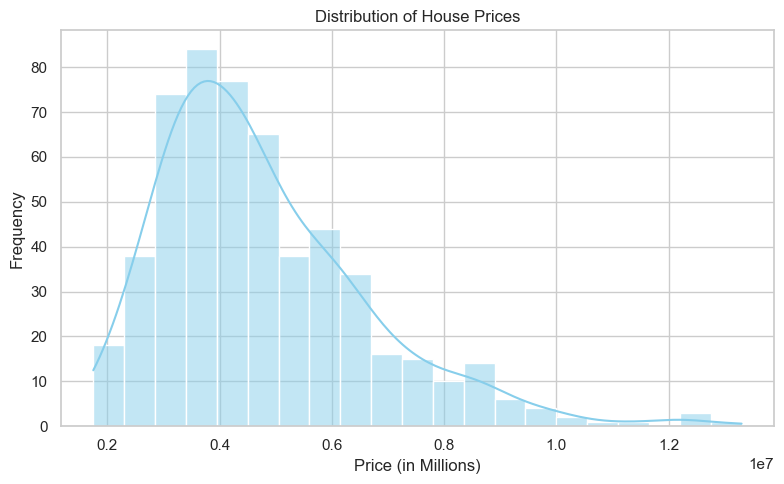

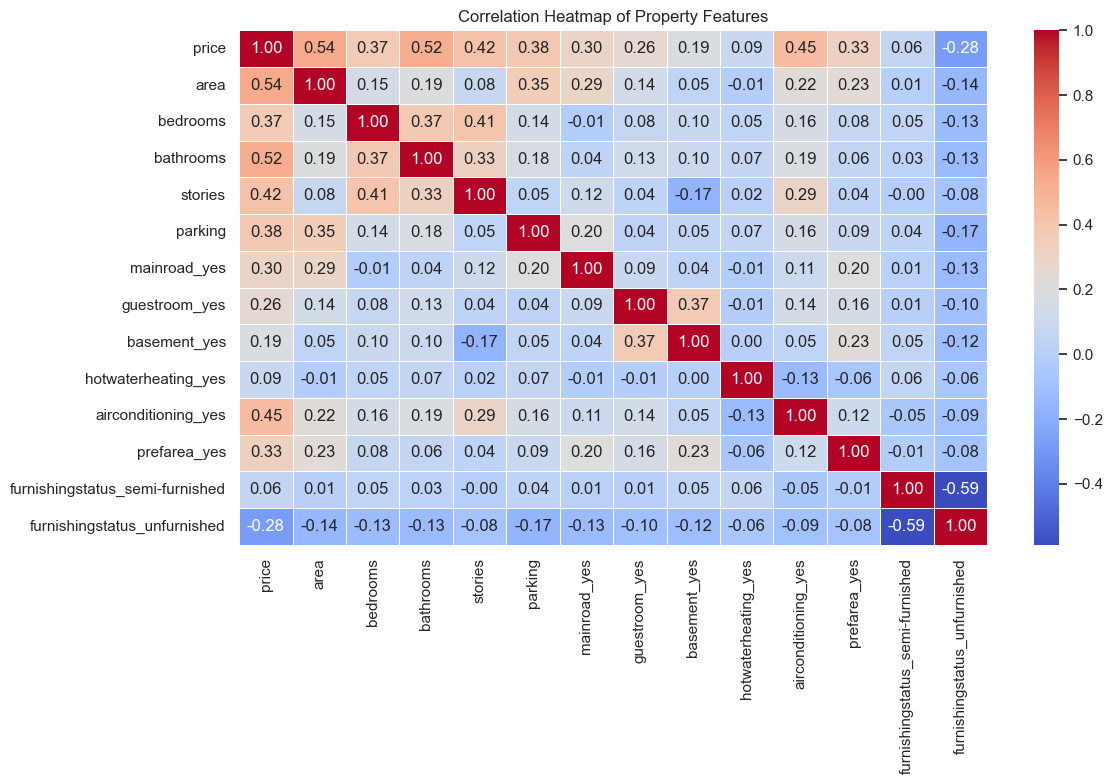

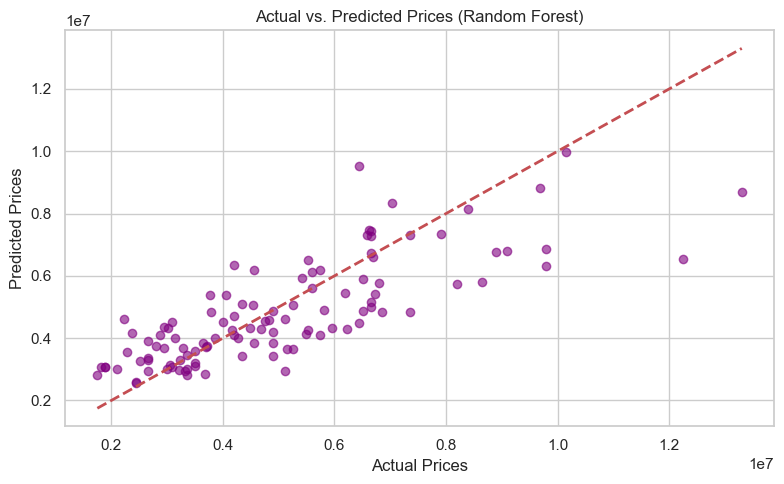

In [6]:
#Data Visualization
sns.set_theme(style="whitegrid")

# Chart 1: Histogram of House Prices
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price (in Millions)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()

# Chart 2: Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Property Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Chart 3: Actual vs Predicted Prices Scatter Plot (Random Forest)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices (Random Forest)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

In [7]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(5))

               Feature  Importance
0                 area    0.468430
2            bathrooms    0.151483
9  airconditioning_yes    0.062672
4              parking    0.057455
3              stories    0.057133


In [ ]:
##Based on our modeling, property area (46.84% importance) and the number of bathrooms (15.15% importance) influence house prices the most. In plain terms, our best model (Linear Regression) was moderately accurate, explaining 65.29% of the variations in market prices, with an average prediction error of roughly $970,043. What surprised us in the data was that having air conditioning had a significantly higher correlation with price (0.45) than the actual number of bedrooms (0.37), proving modern comfort features outweigh basic room counts. Moving forward, we recommend that the real estate business advise clients to prioritize installing air conditioning and remodeling bathrooms over adding extra bedrooms to maximize property flipping returns.